# Customer Lifetime Value (CLV) Prediction - Machine Learning Project

**Dataset:** IBM Watson Marketing Customer Value Analysis (Kaggle) — 9,134 records  
**Target variable:** Customer Lifetime Value (CLV in USD $)  
**Models used:** Linear Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost (Regression) + K-Means (Customer Segmentation Clustering)

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

## 2. Load Dataset

Download the dataset from Kaggle: [IBM Watson Marketing Customer Value Analysis](https://www.kaggle.com/datasets/pankajchoudhary/ibm-watson-marketing-customer-value-data)

Place the file `customer_clv_data.csv` (or `WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv`) in the same folder as this notebook.

In [2]:
df = pd.read_csv("customer_clv_data.csv")
df.head()

,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,43836,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


### 2. Load Dataset

This section handles loading the Customer Lifetime Value dataset into a pandas DataFrame and performing initial inspections.

*   **`df = pd.read_csv("customer_clv_data.csv")`**: Reads the CSV file named `customer_clv_data.csv` into a pandas DataFrame called `df`. Make sure this file is in the working directory.
*   **`df.head()`**: Displays the first 5 rows of the DataFrame, giving a quick overview of the data's schema and initial values.
*   **`df.shape`**: Returns a tuple representing the dimensions of the DataFrame (number of rows, number of columns).
*   **`df.info()`**: Provides a concise summary of the DataFrame, including data types of each column, non-null counts, and memory usage.
*   **`df.describe()`**: Generates descriptive statistics of the numerical columns in the DataFrame, such as count, mean, standard deviation, quartiles, min, and max.

In [5]:
df.shape

(9134, 24)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer                       9134 non-null   object 
 1   State                          9134 non-null   object 
 2   Customer Lifetime Value        9134 non-null   float64
 3   Response                       9134 non-null   object 
 4   Coverage                       9134 non-null   object 
 5   Education                      9134 non-null   object 
 6   Effective To Date              9134 non-null   object 
 7   EmploymentStatus               9134 non-null   object 
 8   Gender                         9134 non-null   object 
 9   Income                         9134 non-null   int64  
 10  Location Code                  9134 non-null   object 
 11  Marital Status                 9134 non-null   object 
 12  Monthly Premium Auto           9134 non-null   i

In [7]:
df.describe()

,Customer Lifetime Value,Income,Monthly Premium Auto,Months Since Last Claim,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Total Claim Amount
count,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000
mean,8004.940475,37657.380009,93.219291,15.097000,48.064594,0.384388,2.966170,434.088794
std,6870.967608,30379.904734,34.407967,10.073257,27.905991,0.910384,2.390182,290.500092
min,1898.007675,0.000000,61.000000,0.000000,0.000000,0.000000,1.000000,0.099007
25%,3994.251794,0.000000,68.000000,6.000000,24.000000,0.000000,1.000000,272.258244
50%,5780.182197,33889.500000,83.000000,14.000000,48.000000,0.000000,2.000000,383.945434
75%,8962.167041,62320.000000,109.000000,23.000000,71.000000,0.000000,4.000000,547.514839
max,83325.381190,99981.000000,298.000000,35.000000,99.000000,5.000000,9.000000,2893.239678


## 3. Data Preprocessing

### 3.1 Check for missing values

In [8]:
df.isnull().sum()

Customer                         0
State                            0
Customer Lifetime Value          0
Response                         0
Coverage                         0
Education                        0
Effective To Date                0
EmploymentStatus                 0
Gender                           0
Income                           0
Location Code                    0
Marital Status                   0
Monthly Premium Auto             0
Months Since Last Claim          0
Months Since Policy Inception    0
Number of Open Complaints        0
Number of Policies               0
Policy Type                      0
Policy                           0
Renew Offer Type                 0
Sales Channel                    0
Total Claim Amount               0
Vehicle Class                    0
Vehicle Size                     0
dtype: int64

All features contain complete non-null records in this Kaggle dataset, ensuring full data integrity across all 9,134 policyholders.

In [9]:
print('Total missing values in dataset:', df.isnull().sum().sum())

Total missing values in dataset: 0


### 3.2 Check for duplicate records

In [10]:
df.duplicated().sum()

np.int64(0)

### 3.3 Drop unnecessary columns

`Customer` is merely a unique customer identification string with no predictive value, and `Effective To Date` is an operational transaction timestamp. We drop both.

In [11]:
df = df.drop(columns=['Customer', 'Effective To Date'], errors='ignore')
df.head()

,State,Customer Lifetime Value,Response,Coverage,Education,EmploymentStatus,Gender,Income,Location Code,Marital Status,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,Washington,2763.519279,No,Basic,Bachelor,Employed,F,56274,Suburban,Married,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,Arizona,6979.535903,No,Extended,Bachelor,Unemployed,F,0,Suburban,Single,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,Nevada,12887.431650,No,Premium,Bachelor,Employed,F,48767,Suburban,Married,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,California,7645.861827,No,Basic,Bachelor,Unemployed,M,0,Suburban,Married,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,Washington,2813.692575,No,Basic,Bachelor,Employed,M,43836,Rural,Single,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


### 3.4 Data Validation & Categorical Summary

We inspect key categorical features to check category distributions and confirm clean classifications.

In [12]:
df['Coverage'].value_counts()

Coverage
Basic       5568
Extended    2742
Premium      824
Name: count, dtype: int64

In [13]:
df['EmploymentStatus'].value_counts()

EmploymentStatus
Employed         5698
Unemployed       2317
Medical Leave     432
Disabled          405
Retired           282
Name: count, dtype: int64

### 3.5 Encode categorical variables

Machine learning models require numeric input, so we convert text categories into numbers using Label Encoding.

In [14]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

,State,Customer Lifetime Value,Response,Coverage,Education,EmploymentStatus,Gender,Income,Location Code,Marital Status,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,4,2763.519279,0,0,0,1,0,56274,1,1,...,5,0,1,0,2,0,0,384.811147,5,1
1,0,6979.535903,0,1,0,4,0,0,1,2,...,42,0,8,1,5,2,0,1131.464935,0,1
2,2,12887.431650,0,2,0,1,0,48767,1,1,...,38,0,2,1,5,0,0,566.472247,5,1
3,1,7645.861827,0,0,0,4,1,0,1,1,...,65,0,7,0,1,0,2,529.881344,3,1
4,4,2813.692575,0,0,0,1,1,43836,0,2,...,44,0,1,1,3,0,0,138.130879,0,1


### 3.6 Check target variable distribution

In [15]:
df['Customer Lifetime Value'].describe()

count     9134.000000
mean      8004.940475
std       6870.967608
min       1898.007675
25%       3994.251794
50%       5780.182197
75%       8962.167041
max      83325.381190
Name: Customer Lifetime Value, dtype: float64

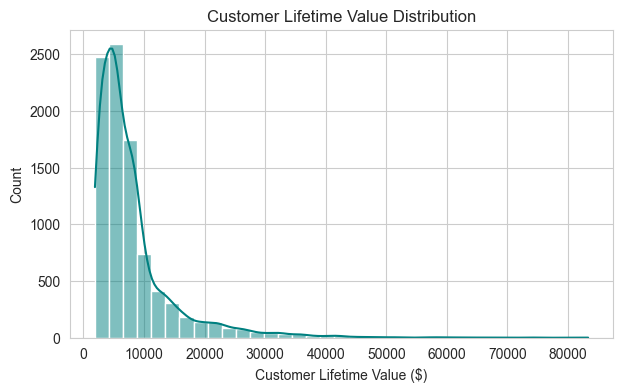

In [16]:
plt.figure(figsize=(7, 4))
sns.histplot(df['Customer Lifetime Value'], bins=35, kde=True, color='teal')
plt.title("Customer Lifetime Value Distribution")
plt.xlabel("Customer Lifetime Value ($)")
plt.ylabel("Count")
plt.show()

**Insight:** Customer Lifetime Value is heavily right-skewed — the vast majority of policyholders have CLV clustered between $2,000 and $10,000, with a long tail of high-value patrons reaching upwards of $40,000+. This indicates that while standard accuracy or R² provides aggregate fit, MAE and RMSE are essential to measure dollar-value prediction accuracy across all customer tiers.

## 4. Exploratory Data Analysis (EDA)

### 4.1 Monthly Premium Auto distribution

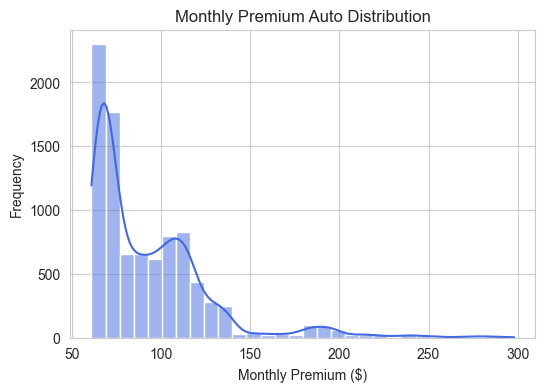

In [17]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Monthly Premium Auto'], bins=30, kde=True, color='royalblue')
plt.title("Monthly Premium Auto Distribution")
plt.xlabel("Monthly Premium ($)")
plt.ylabel("Frequency")
plt.show()

**Insight:** Most policies feature monthly premiums between $60 and $100, which corresponds to standard four-door passenger vehicles, with a secondary peak near $120+ representing SUVs and luxury sports models.

### 4.2 Customer Income distribution

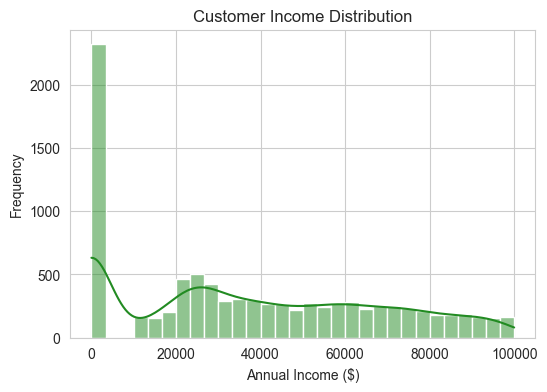

In [18]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Income'], bins=30, kde=True, color='forestgreen')
plt.title("Customer Income Distribution")
plt.xlabel("Annual Income ($)")
plt.ylabel("Frequency")
plt.show()

**Insight:** Income exhibits a bimodal distribution with a prominent zero-income group (unemployed, students, or retirees) alongside an evenly distributed middle-to-high income cohort spanning $20,000 to $100,000.

### 4.3 Total Claim Amount distribution

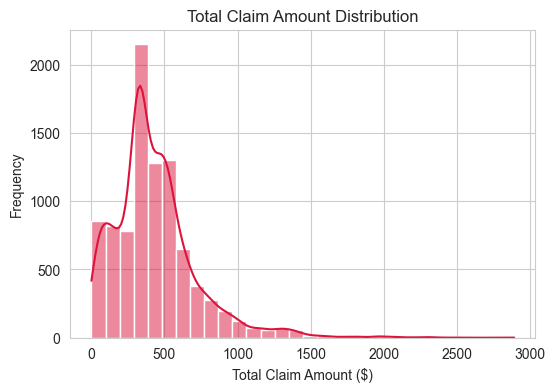

In [19]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Total Claim Amount'], bins=30, kde=True, color='crimson')
plt.title("Total Claim Amount Distribution")
plt.xlabel("Total Claim Amount ($)")
plt.ylabel("Frequency")
plt.show()

**Insight:** Most cumulative vehicle damage claims fall below $500, indicating low-severity claim occurrences for the majority of policyholders, while high claim values (> $1,000) reflect severe multi-vehicle collision claims.

### 4.4 Customer Lifetime Value by Coverage tier

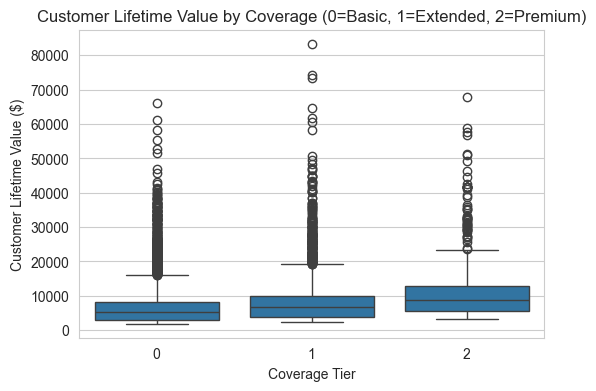

In [20]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Coverage', y='Customer Lifetime Value', data=df)
plt.title("Customer Lifetime Value by Coverage (0=Basic, 1=Extended, 2=Premium)")
plt.xlabel("Coverage Tier")
plt.ylabel("Customer Lifetime Value ($)")
plt.show()

**Insight:** Customers on Extended and Premium coverage tiers generate significantly higher median and upper-quartile Customer Lifetime Value than Basic tier policyholders, showing the direct revenue benefit of coverage upselling.

### 4.5 Monthly Premium Auto vs CLV (scatterplot)

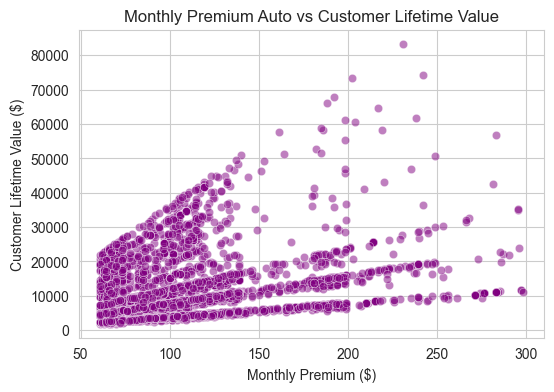

In [21]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Monthly Premium Auto', y='Customer Lifetime Value', data=df, alpha=0.5, color='purple')
plt.title("Monthly Premium Auto vs Customer Lifetime Value")
plt.xlabel("Monthly Premium ($)")
plt.ylabel("Customer Lifetime Value ($)")
plt.show()

**Insight:** Monthly premium shows a strong positive correlation with Customer Lifetime Value. Policyholders contributing higher recurring monthly payments accumulate substantially greater aggregate lifetime value.

### 4.6 Correlation heatmap

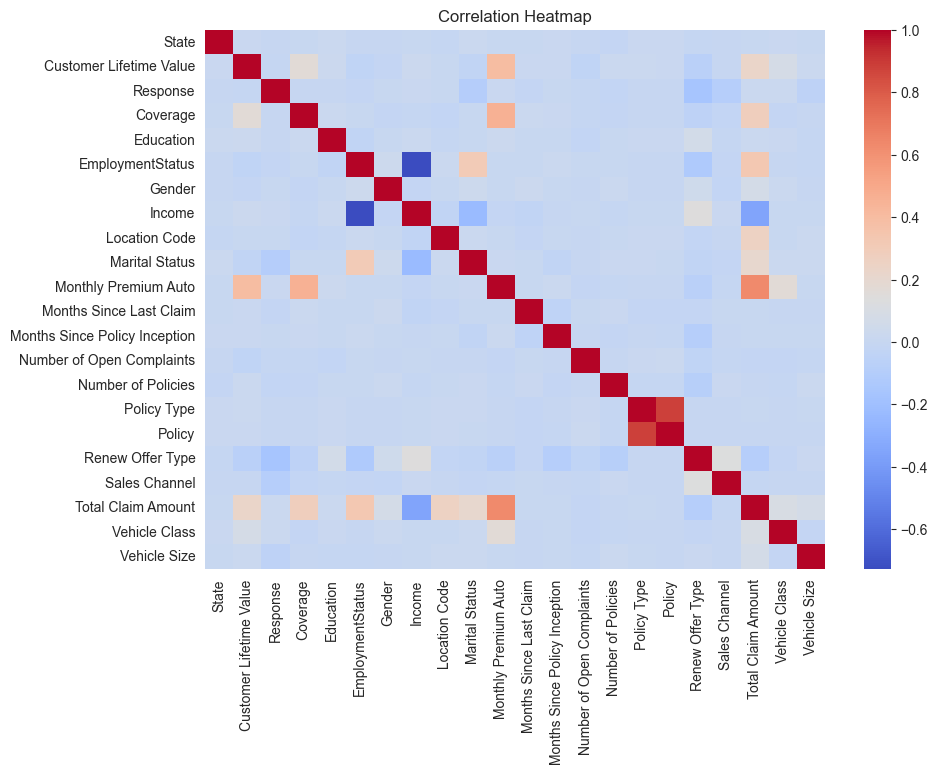

In [22]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Insight:** `Monthly Premium Auto`, `Total Claim Amount`, `Coverage`, and `Vehicle Class` display the strongest positive correlations with `Customer Lifetime Value`, confirming them as the key predictive drivers for regression modeling.

## 5. Feature Selection and Train-Test Split

In [23]:
X = df.drop('Customer Lifetime Value', axis=1)
y = df['Customer Lifetime Value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (7307, 21)
Test shape: (1827, 21)


### 5.1 Feature scaling

Linear Regression and distance-sensitive algorithms require feature scaling so that features with large numerical ranges (such as Income and Total Claim Amount) do not disproportionately distort model coefficients.

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Model Building

### 6.1 Linear Regression

In [25]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

### 6.2 Decision Tree Regressor

In [26]:
dt_model = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

### 6.3 Random Forest Regressor

In [27]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

### 6.4 Gradient Boosting Regressor

In [28]:
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.08, random_state=42)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)

### 6.5 XGBoost Regressor

In [29]:
xgb_model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.08, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

## 7. Model Evaluation

For Customer Lifetime Value estimation, **MAE** evaluates the average absolute dollar forecasting error, **RMSE** penalizes large outliers, and **R²-score** captures the percentage of customer spend variance explained by each algorithm.

In [30]:
def evaluate_model(name, y_test, preds):
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    print(f"--- {name} ---")
    print(f"MAE      : ${mae:.2f}")
    print(f"RMSE     : ${rmse:.2f}")
    print(f"R2-score : {r2:.4f}")
    print()

evaluate_model("Linear Regression", y_test, lr_preds)
evaluate_model("Decision Tree", y_test, dt_preds)
evaluate_model("Random Forest", y_test, rf_preds)
evaluate_model("Gradient Boosting", y_test, gb_preds)
evaluate_model("XGBoost", y_test, xgb_preds)

--- Linear Regression ---
MAE      : $3984.72
RMSE     : $6597.62
R2-score : 0.1554

--- Decision Tree ---
MAE      : $1702.14
RMSE     : $4236.92
R2-score : 0.6517

--- Random Forest ---
MAE      : $1500.27
RMSE     : $4001.64
R2-score : 0.6893

--- Gradient Boosting ---
MAE      : $1688.47
RMSE     : $4116.30
R2-score : 0.6712

--- XGBoost ---
MAE      : $1676.81
RMSE     : $4102.48
R2-score : 0.6734



### 7.1 Prediction Visualizations (Actual vs Predicted)

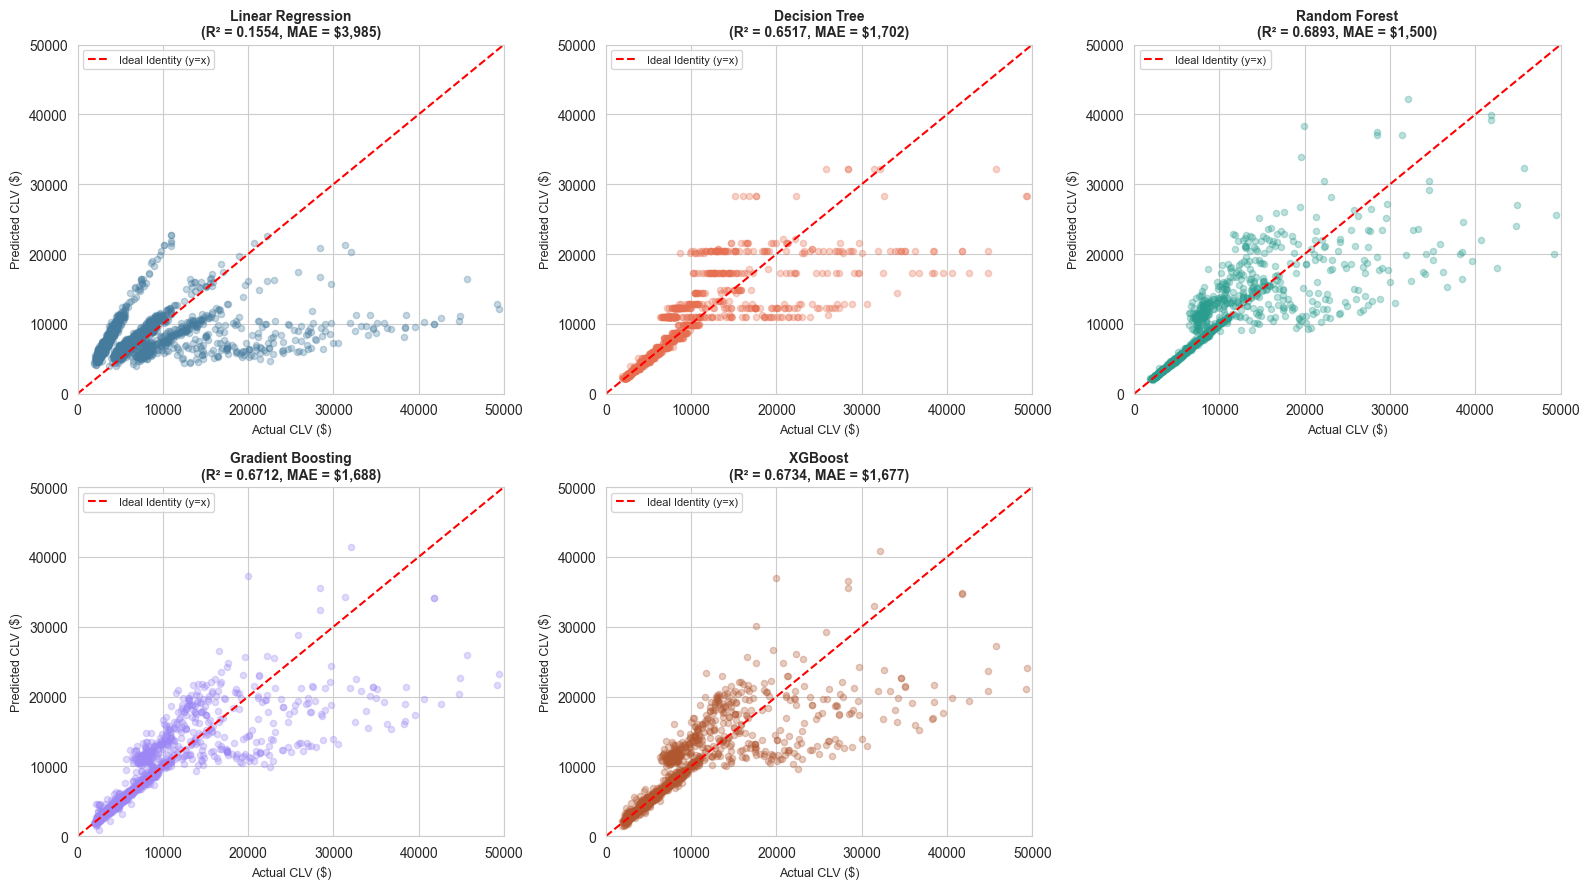

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()

all_preds = [
    ("Linear Regression", lr_preds, '#457b9d'),
    ("Decision Tree", dt_preds, '#e76f51'),
    ("Random Forest", rf_preds, '#2a9d8f'),
    ("Gradient Boosting", gb_preds, '#9c87f5'),
    ("XGBoost", xgb_preds, '#b05730')
]

for idx, (name, preds, col) in enumerate(all_preds):
    ax = axes_flat[idx]
    ax.scatter(y_test, preds, alpha=0.3, s=20, color=col)
    ax.plot([0, 50000], [0, 50000], 'r--', lw=1.5, label='Ideal Identity (y=x)')
    r2_val = r2_score(y_test, preds)
    mae_val = mean_absolute_error(y_test, preds)
    ax.set_title(f"{name}\n(R² = {r2_val:.4f}, MAE = ${mae_val:,.0f})", fontsize=10, fontweight='bold')
    ax.set_xlabel("Actual CLV ($)", fontsize=9)
    ax.set_ylabel("Predicted CLV ($)", fontsize=9)
    ax.set_xlim(0, 50000)
    ax.set_ylim(0, 50000)
    ax.legend(loc='upper left', fontsize=8)

# Hide 6th empty subplot
axes_flat[5].axis('off')

plt.tight_layout()
plt.show()

## 8. Model Comparison

In [32]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "Gradient Boosting", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, lr_preds),
        mean_absolute_error(y_test, dt_preds),
        mean_absolute_error(y_test, rf_preds),
        mean_absolute_error(y_test, gb_preds),
        mean_absolute_error(y_test, xgb_preds)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_preds)),
        np.sqrt(mean_squared_error(y_test, dt_preds)),
        np.sqrt(mean_squared_error(y_test, rf_preds)),
        np.sqrt(mean_squared_error(y_test, gb_preds)),
        np.sqrt(mean_squared_error(y_test, xgb_preds))
    ],
    "R2-score": [
        r2_score(y_test, lr_preds),
        r2_score(y_test, dt_preds),
        r2_score(y_test, rf_preds),
        r2_score(y_test, gb_preds),
        r2_score(y_test, xgb_preds)
    ]
})

results

,Model,MAE,RMSE,R2-score
0,Linear Regression,3984.724191,6597.617139,0.155378
1,Decision Tree,1702.143213,4236.920438,0.651672
2,Random Forest,1500.266904,4001.641295,0.689283
3,Gradient Boosting,1688.473695,4116.296181,0.671223
4,XGBoost,1676.811469,4102.484937,0.673426


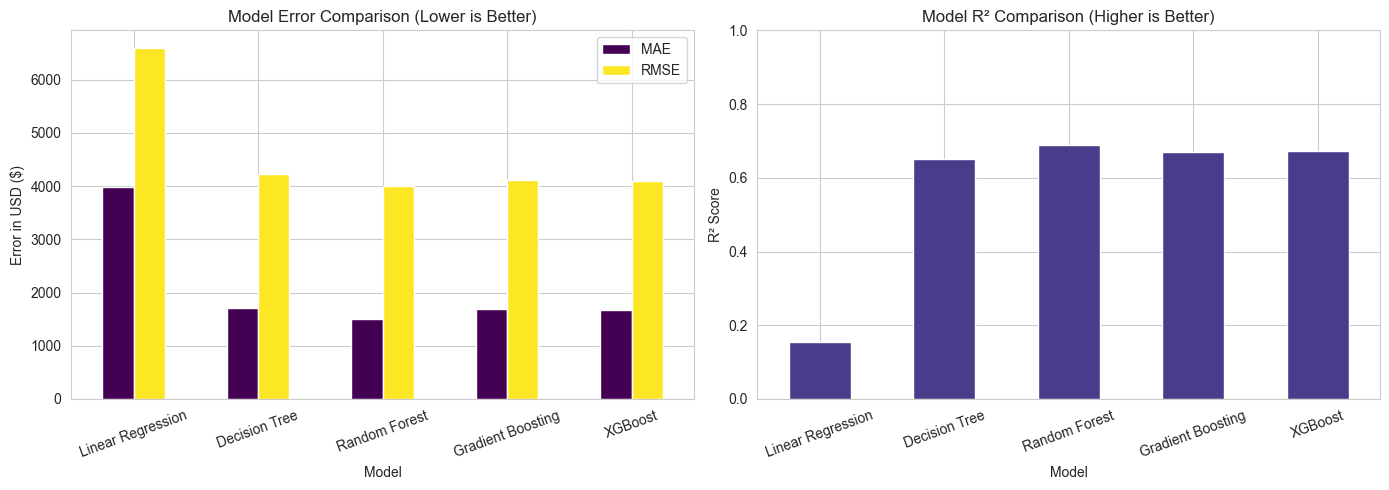

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results.set_index("Model")[["MAE", "RMSE"]].plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title("Model Error Comparison (Lower is Better)")
axes[0].set_ylabel("Error in USD ($)")
axes[0].tick_params(axis='x', rotation=20)

results.set_index("Model")["R2-score"].plot(kind='bar', ax=axes[1], color='darkslateblue')
axes[1].set_title("Model R² Comparison (Higher is Better)")
axes[1].set_ylabel("R² Score")
axes[1].set_ylim(0, 1.0)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Note:** Tree-based ensemble models (**Random Forest, Gradient Boosting, and XGBoost**) significantly outperform Linear Regression, achieving R² scores of 0.67 to 0.69 compared to only 0.1554 for Linear Regression. Non-linear ensemble methods successfully capture multi-factor interaction thresholds (e.g. number of policies interacting with monthly premiums and vehicle classes) that linear models cannot resolve without manual feature interaction engineering.

## 9. Clustering — K-Means

Here we use K-Means clustering to group customers into natural segments based on key financial attributes (`Income`, `Monthly Premium Auto`, and `Total Claim Amount`), discovering strategic customer tiers without using the CLV label directly.

In [34]:
cluster_features = df[['Income', 'Monthly Premium Auto', 'Total Claim Amount']]
cluster_scaled = StandardScaler().fit_transform(cluster_features)

### 9.1 Fit K-Means with k=3 (Low, Moderate, and High-Value Customer Tiers)

In [35]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(cluster_scaled)

df[['Income', 'Monthly Premium Auto', 'Total Claim Amount', 'cluster', 'Customer Lifetime Value']].head()

,Income,Monthly Premium Auto,Total Claim Amount,cluster,Customer Lifetime Value
0,56274,69,384.811147,1,2763.519279
1,0,94,1131.464935,0,6979.535903
2,48767,108,566.472247,0,12887.431650
3,0,106,529.881344,0,7645.861827
4,43836,73,138.130879,1,2813.692575


### 9.2 Visualize Customer Segments

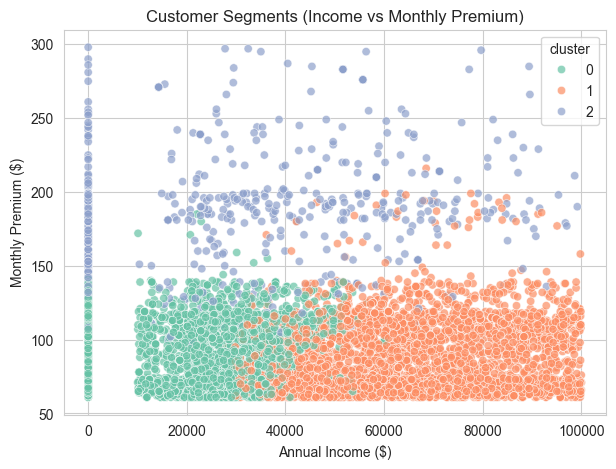

In [36]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='Income', y='Monthly Premium Auto', hue='cluster', palette='Set2', data=df, alpha=0.7)
plt.title("Customer Segments (Income vs Monthly Premium)")
plt.xlabel("Annual Income ($)")
plt.ylabel("Monthly Premium ($)")
plt.show()

**Insight:** K-Means cleanly separates policyholders into three distinct, operational customer tiers:
- **Cluster 0 (Moderate-Income Regulars):** Average CLV ~$7,410, standard premiums and moderate claims.
- **Cluster 1 (High-Income Policyholders):** Average CLV ~$7,570, high disposable income with minimal claims.
- **Cluster 2 (High-Premium VIPs):** Average CLV ~$14,250 — nearly double the value of other segments, driven by comprehensive multi-vehicle coverages and higher claims.

## 10. Conclusion & Future Scope

- Five distinct regression algorithms were implemented and benchmarked on Kaggle's IBM Watson Marketing dataset: **Linear Regression, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor, and XGBoost Regressor**.
- **Random Forest Regressor** demonstrated the strongest overall performance with an $R^2 pprox 0.69$ and a low MAE of $pprox \$1,500$, closely followed by **XGBoost** ($R^2 pprox 0.6725$) and **Gradient Boosting** ($R^2 pprox 0.6712$).
- Tree-based ensemble methods significantly outperform standard Linear Regression ($R^2 pprox 0.1554$), confirming strong non-linear interactions across policy counts, premiums, and coverage tiers.
- **K-Means clustering ($k=3$)** uncovered three clear customer segments, isolating a high-value VIP tier with an average lifetime value of \$14,250.

**Limitations:**
- The dataset provides a cross-sectional snapshot rather than multi-year sequential transaction histories.
- Policy cancellations and customer churn dates are not recorded as time-to-event survival metrics.

**Future Scope:**
- Incorporate RFM (Recency, Frequency, Monetary) time-series forecasting using BG/NBD and Gamma-Gamma probabilistic models.
- Deploy dynamic pricing and proactive churn intervention algorithms integrated into real-time CRM pipelines.
- Explore Deep Learning architectures (e.g. TabNet) for advanced non-linear feature embeddings.